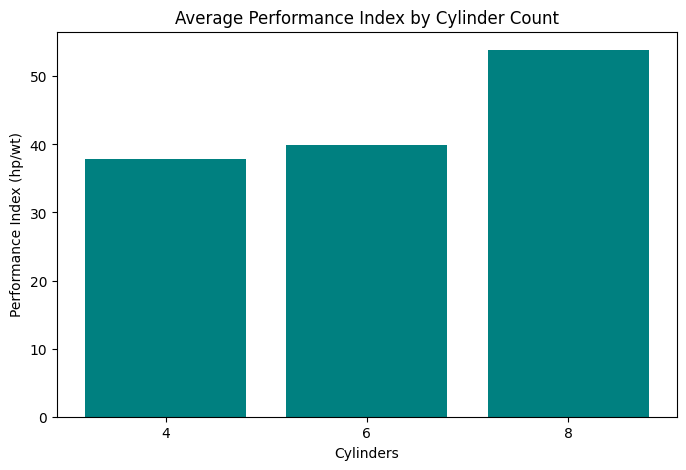

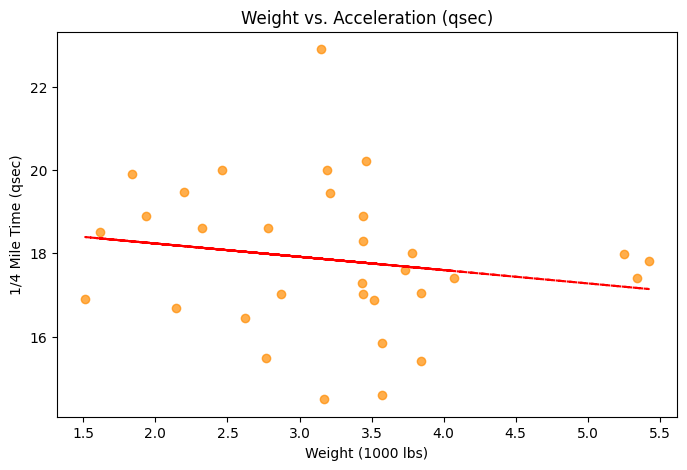

C:\Users\Malik\AppData\Local\Temp\ipykernel_15940\1549958159.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df[df['am']==0]['mpg'], df[df['am']==1]['mpg']], labels=['Auto', 'Manual'])
C:\Users\Malik\AppData\Local\Temp\ipykernel_15940\1549958159.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df[df['am']==0]['hp'], df[df['am']==1]['hp']], labels=['Auto', 'Manual'])


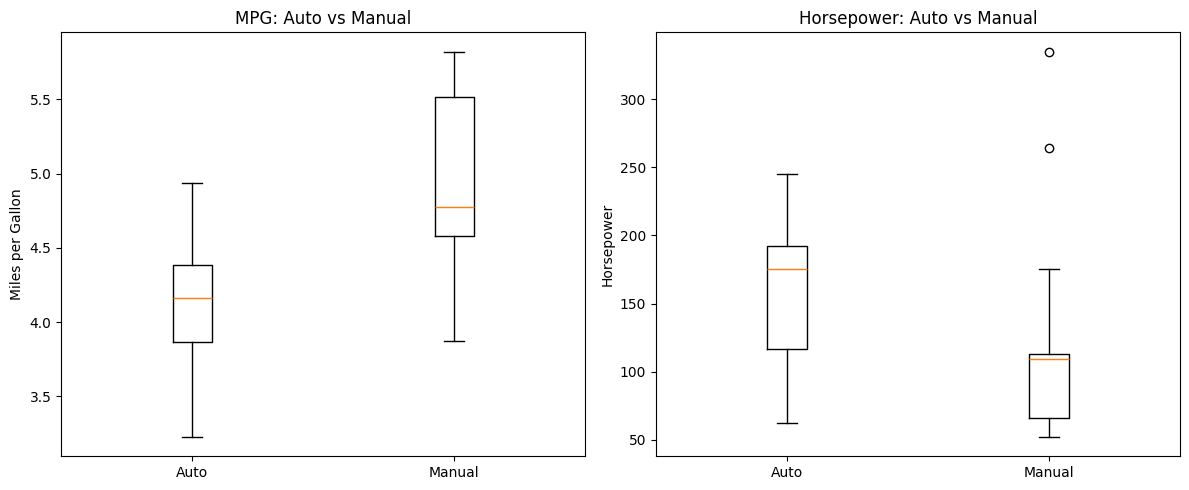

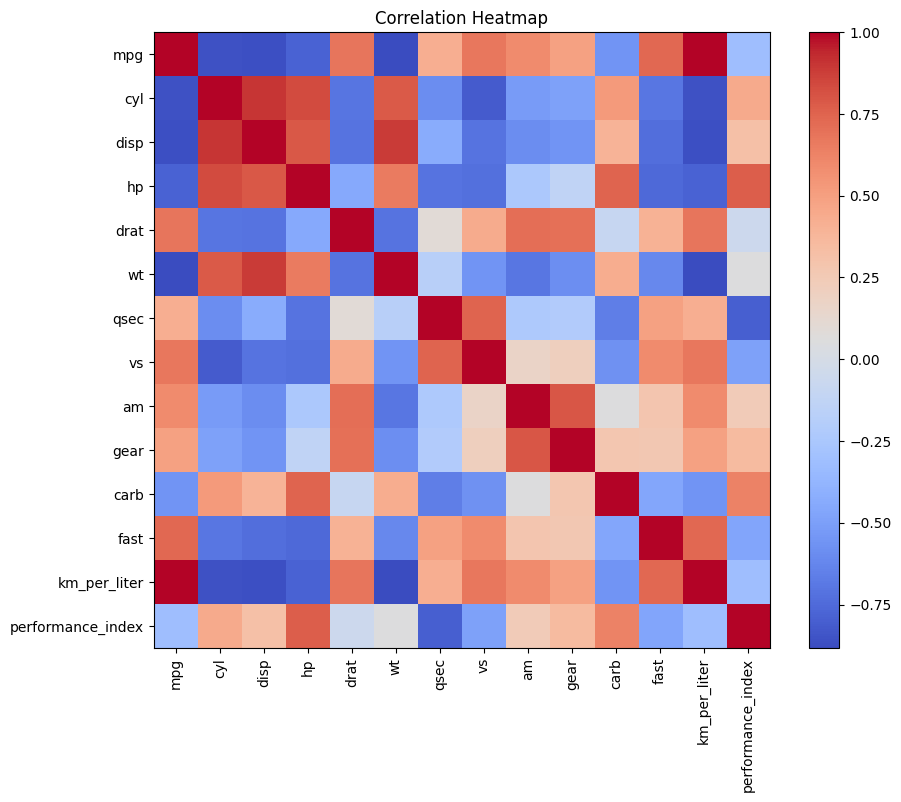

Analysis complete. All figures saved as PNG files.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




df['km_per_liter'] = df['mpg'] * 0.425144 

df['performance_index'] = df['hp'] / df['wt'] 


url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df = pd.read_csv(url)



perf_by_cyl = df.groupby('cyl')['performance_index'].mean()
plt.figure(figsize=(8, 5))
plt.bar(perf_by_cyl.index.astype(str), perf_by_cyl.values, color='teal')
plt.title('Average Performance Index by Cylinder Count')
plt.xlabel('Cylinders')
plt.ylabel('Performance Index (hp/wt)')
plt.savefig('figure1.png') 
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['wt'], df['qsec'], alpha=0.7, color='darkorange')
m, c = np.polyfit(df['wt'], df['qsec'], 1) 
plt.plot(df['wt'], m*df['wt'] + c, color='red', linestyle='--')
plt.title('Weight vs. Acceleration (qsec)')
plt.xlabel('Weight (1000 lbs)')
plt.ylabel('1/4 Mile Time (qsec)')
plt.savefig('figure2.png')
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.boxplot([df[df['am']==0]['mpg'], df[df['am']==1]['mpg']], labels=['Auto', 'Manual'])
ax1.set_title('MPG: Auto vs Manual')
ax1.set_ylabel('Miles per Gallon')


ax2.boxplot([df[df['am']==0]['hp'], df[df['am']==1]['hp']], labels=['Auto', 'Manual'])
ax2.set_title('Horsepower: Auto vs Manual')
ax2.set_ylabel('Horsepower')

plt.tight_layout()
plt.savefig('figure3.png')
plt.show()

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
plt.imshow(correlation, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation)), correlation.columns)
plt.title('Correlation Heatmap')
plt.savefig('figure4.png')
plt.show()
